In [7]:
import pandas as pd
df = pd.read_csv("C:\\Users\\atchi\\Downloads\\E-commerce Customer Behavior - Sheet1.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB
None


In [8]:
print(df.head())

   Customer ID  Gender  Age           City Membership Type  Total Spend  \
0          101  Female   29       New York            Gold      1120.20   
1          102    Male   34    Los Angeles          Silver       780.50   
2          103  Female   43        Chicago          Bronze       510.75   
3          104    Male   30  San Francisco            Gold      1480.30   
4          105    Male   27          Miami          Silver       720.40   

   Items Purchased  Average Rating  Discount Applied  \
0               14             4.6              True   
1               11             4.1             False   
2                9             3.4              True   
3               19             4.7             False   
4               13             4.0              True   

   Days Since Last Purchase Satisfaction Level  
0                        25          Satisfied  
1                        18            Neutral  
2                        42        Unsatisfied  
3               

In [9]:
print(df.isnull().sum())

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64


In [10]:
df.drop_duplicates(inplace=True)
df.fillna(0, inplace=True)

In [13]:
total_spend = df['Total Spend'].sum()
print("Total Spend:", total_spend)

Total Spend: 295883.6


In [15]:
City_Spend = df.groupby('City')['Total Spend'].sum()
print(City_Spend)

City
Chicago          28993.2
Houston          25919.9
Los Angeles      47524.0
Miami            40042.6
New York         68737.1
San Francisco    84666.8
Name: Total Spend, dtype: float64


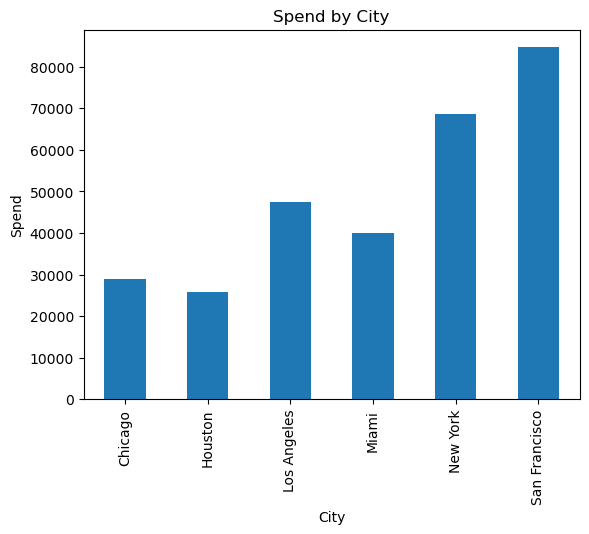

In [22]:
import matplotlib.pyplot as plt
City_Spend.plot(kind='bar')
plt.title("Spend by City")
plt.xlabel("City")
plt.ylabel("Spend")
plt.show()

In [25]:
top_customers = df.groupby('Customer ID')['Total Spend'].sum()
top_customers = top_customers.sort_values(
    ascending=False
)
print(top_customers.head(10))

Customer ID
110    1520.1
128    1500.1
218    1500.1
331    1500.1
188    1500.1
260    1500.1
158    1500.1
290    1500.1
409    1490.1
319    1490.1
Name: Total Spend, dtype: float64


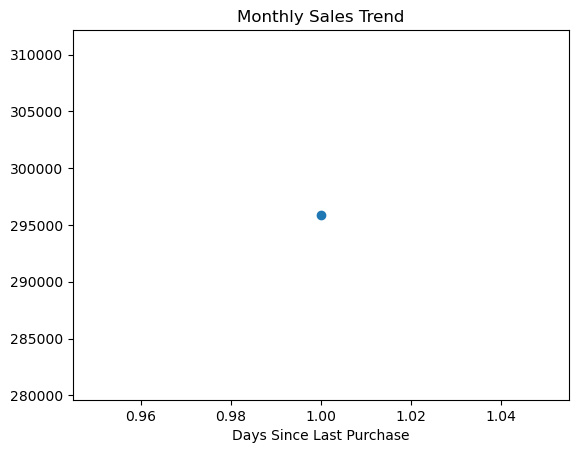

In [27]:
df['Days Since Last Purchase'] = pd.to_datetime(df['Days Since Last Purchase'])
monthly_sales = df.groupby(
    df['Days Since Last Purchase'].dt.month
)['Total Spend'].sum()
monthly_sales.plot(
    kind='line',
    marker='o'
)
plt.title("Monthly Sales Trend")
plt.show()

In [28]:
clv = df.groupby(
    'Customer ID'
)['Total Spend'].sum()
print(clv.sort_values(
    ascending=False
))

Customer ID
110    1520.1
128    1500.1
218    1500.1
331    1500.1
188    1500.1
        ...  
315     420.8
232     420.8
142     420.8
172     420.8
357     410.8
Name: Total Spend, Length: 350, dtype: float64


In [29]:
snapshot_date = df['Days Since Last Purchase'].max()
rfm = df.groupby('Customer ID').agg({
    'Days Since Last Purchase': lambda x:
        (snapshot_date - x.max()).days,
    'Customer ID':'count',
    'Total Spend':'sum'
})
rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]
print(rfm.head())

             Recency  Frequency  Monetary
Customer ID                              
101                0          1   1120.20
102                0          1    780.50
103                0          1    510.75
104                0          1   1480.30
105                0          1    720.40
